# Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Shape

In [2]:
data = ["foia-7a-fy1991-fy1999-asof-260331.csv",
        "foia-7a-fy2000-fy2009-asof-260331.csv",
        "foia-7a-fy2010-fy2019-asof-260331.csv",
        "foia-7a-fy2020-present-asof-260331.csv"]

df = pd.concat((pd.read_csv(i) for i in data), ignore_index=True)
df.head()

/var/folders/1c/47fsk5z56lq4c2qq6c1rfj7r0000gn/T/ipykernel_9861/3736347035.py:6: DtypeWarning: Columns (0: bankzip, 1: franchisecode, 2: collateralind) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(i) for i in data), ignore_index=True)
/var/folders/1c/47fsk5z56lq4c2qq6c1rfj7r0000gn/T/ipykernel_9861/3736347035.py:6: DtypeWarning: Columns (0: bankzip, 1: fixedorvariableinterestind, 2: franchisecode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(i) for i in data), ignore_index=True)
/var/folders/1c/47fsk5z56lq4c2qq6c1rfj7r0000gn/T/ipykernel_9861/3736347035.py:6: DtypeWarning: Columns (0: bankzip) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(i) for i in data), ignore_index=True)
/var/folders/1c/47fsk5z56lq4c2qq6c1rfj7r0000gn/T/ipykernel_9861/3736347035.py:6: DtypeWarning: Columns (0: chargeoffdate) have mixed types. S

,asofdate,program,locationid,borrname,borrstreet,borrcity,borrstate,borrzip,bankname,bankfdicnumber,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,soldsecmrktind
0,3/31/2026,7A,75939.0,MR DONUT,N2761 SHADY ACRE DRIVE,NEW LONDON,WI,54961,"Associated Bank, National Association",5296.0,...,CORPORATION,Less than 4 years old but at least 3,P I F,7/31/2005,NaN,0.0,False,0.0,False,Y
1,3/31/2026,7A,21548.0,COMPUTEAM,15028 S. CICERO,HOMEWOOD,IL,60452,"Bank of Homewood, National Association",NaN,...,CORPORATION,Less than 4 years old but at least 3,P I F,7/31/2005,NaN,0.0,False,0.0,False,NaN
2,3/31/2026,7A,150326.0,NATIONAL ENVIRONMENTAL SERVICE,12331 E. 60TH ST.,TULSA,OK,74146,Boatmen's First National Bank of Oklahoma,NaN,...,CORPORATION,Less than 4 years old but at least 3,P I F,7/31/2005,NaN,0.0,False,0.0,False,NaN
3,3/31/2026,7A,20144.0,MAGGIE'S COZY CLUB,127 E MAIN ST,RIGBY,ID,83442,The Bank of Commerce,18059.0,...,INDIVIDUAL,Less than 4 years old but at least 3,P I F,7/31/2005,NaN,0.0,False,0.0,False,NaN
4,3/31/2026,7A,5570.0,TERI BURGER,14752 BADILLO,BALDWIN PARK,CA,91706,General Bank,NaN,...,INDIVIDUAL,Less than 4 years old but at least 3,P I F,7/31/2005,NaN,0.0,False,0.0,False,Y


In [3]:
print(df.shape[0], df.shape[1])

1947098 43


In [4]:
df.dtypes

asofdate                          str
program                           str
locationid                    float64
borrname                          str
borrstreet                        str
borrcity                          str
borrstate                         str
borrzip                         int64
bankname                          str
bankfdicnumber                float64
bankncuanumber                float64
bankstreet                        str
bankcity                          str
bankstate                         str
bankzip                        object
grossapproval                 float64
sbaguaranteedapproval         float64
approvaldate                      str
approvalfy                      int64
firstdisbursementdate             str
processingmethod                  str
subprogram                        str
initialinterestrate           float64
fixedorvariableinterestind     object
terminmonths                    int64
naicscode                     float64
naicsdescrip

### Target

We are only concerned with loans that are paid in full (PIF) or charged off (CHGOFF) since those loans are completed. This will be a binary classification with CHGOFF being loans that defaulted.

In [5]:
df["loanstatus"].value_counts()

loanstatus
P I F             1169782
CURR               262021
CANCLD             238349
CHGOFF             143101
CLSLN               75735
COMMIT              23773
PURCH(NOT C/O)      14444
LIQUID               8554
DELINQ               5530
PSTDUE               2678
SOLDNC               2087
DEFERD                733
SOLDCO                311
Name: count, dtype: int64

In [6]:
df = df[df["loanstatus"].isin(["P I F", "CHGOFF"])].copy()
df["default"] = (df["loanstatus"] == "CHGOFF").astype(int)
print(df["default"].value_counts())
print(f"{df["default"].mean():.2%}")

default
0    1169782
1     143101
Name: count, dtype: int64
10.90%


### Cols known at loan application

The goal is to predict whether a loan will default before the loan is disbursed to minimize risky loans. Several columns represent high cardinality administrative details or information known after the loan is approved or completed. These columns will be dropped.

In [7]:
drop_cols = [
        "asofdate", "program", "locationid", "borrname", "borrstreet",
       "borrcity", "borrzip", "bankname", "bankfdicnumber",
       "bankncuanumber", "bankstreet", "bankcity", "bankstate", "bankzip",
        "sbaguaranteedapproval", "approvaldate",
       "firstdisbursementdate", "processingmethod", "subprogram", "naicsdescription",
       "franchisecode", "projectcounty", "sbadistrictoffice", "congressionaldistrict",
       "paidinfulldate", "chargeoffdate", "grosschargeoffamount", "soldsecmrktind"
]
df.drop(columns=drop_cols, inplace=True)
df.columns

Index(['borrstate', 'grossapproval', 'approvalfy', 'initialinterestrate',
       'fixedorvariableinterestind', 'terminmonths', 'naicscode',
       'franchisename', 'projectstate', 'businesstype', 'businessage',
       'loanstatus', 'revolverstatus', 'jobssupported', 'collateralind',
       'default'],
      dtype='str')

In [8]:
df.describe()

,grossapproval,approvalfy,initialinterestrate,terminmonths,naicscode,jobssupported,default
count,1.312883e+06,1.312883e+06,521328.000000,1.312883e+06,1.156517e+06,1.312883e+06,1.312883e+06
mean,2.528431e+05,2.006982e+03,6.609785,1.103074e+02,5.197580e+05,7.508674e+00,1.089975e-01
std,4.781856e+05,7.938891e+00,1.705524,7.552646e+01,1.743434e+05,2.160823e+01,3.116362e-01
min,-1.200000e+05,1.991000e+03,0.000000,0.000000e+00,1.111100e+05,0.000000e+00,0.000000e+00
25%,3.400000e+04,2.001000e+03,5.500000,6.000000e+01,4.243300e+05,0.000000e+00,0.000000e+00
50%,9.750000e+04,2.007000e+03,6.000000,8.400000e+01,5.311100e+05,3.000000e+00,0.000000e+00
75%,2.500000e+05,2.014000e+03,7.500000,1.200000e+02,6.242100e+05,8.000000e+00,0.000000e+00
max,5.000000e+06,2.026000e+03,16.500000,5.690000e+02,9.281200e+05,9.500000e+03,1.000000e+00


### Missing Values

Rows with missing values will be dropped since it is most likely due to reporting issues and it will be easier to interpret. We still have many rows to work with and inputting them will heavily affect the distribution. We will make a franchise flag to see if larger brands are significant. We will also condense NAICS codes to their first two digits and map them to their respective industries.

In [9]:
print(df.isnull().sum())

borrstate                           0
grossapproval                       0
approvalfy                          0
initialinterestrate            791555
fixedorvariableinterestind     791554
terminmonths                        0
naicscode                      156366
franchisename                 1222269
projectstate                        0
businesstype                     2595
businessage                      1336
loanstatus                          0
revolverstatus                      0
jobssupported                       0
collateralind                   14387
default                             0
dtype: int64


In [10]:
df["is_franchise"] = df["franchisename"].notna().astype(int)
df.drop(columns=["franchisename"], inplace=True)
df.dropna(inplace=True)

In [11]:
naics_dict = {
    "11": "Agriculture",
    "21": "Mining",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale",
    "44": "Retail", "45": "Retail",
    "48": "Transportation", "49": "Transportation",
    "51": "Information",
    "52": "Finance",
    "53": "Real Estate",
    "54": "Professional Services",
    "55": "Management",
    "56": "Administrative",
    "61": "Education",
    "62": "Health Care",
    "71": "Arts & Entertainment",
    "72": "Food & Accommodation",
    "81": "Other Services",
    "92": "Public Administration",
}

df["naics_2"] = ((df["naicscode"].astype(int) // 10000).astype(str)).map(naics_dict)
df.drop(columns=["naicscode"], inplace=True)

In [12]:
print(df["naics_2"].nunique())
print(df["naics_2"].value_counts())

20
naics_2
Retail                   70588
Food & Accommodation     64924
Construction             57639
Professional Services    52329
Health Care              46967
Other Services           44875
Manufacturing            40779
Transportation           29700
Wholesale                27746
Administrative           25021
Arts & Entertainment     14530
Real Estate              11536
Finance                   9337
Agriculture               8388
Education                 7018
Information               6222
Mining                    1524
Utilities                  496
Management                 299
Public Administration      101
Name: count, dtype: int64


In [13]:
print(df.groupby("naics_2")["default"].mean().sort_values(ascending=False))

naics_2
Public Administration    0.118812
Transportation           0.096936
Arts & Entertainment     0.096628
Wholesale                0.086643
Retail                   0.086332
Education                0.084639
Construction             0.083607
Food & Accommodation     0.082589
Information              0.079396
Other Services           0.078084
Administrative           0.077855
Utilities                0.074597
Professional Services    0.070305
Manufacturing            0.064592
Mining                   0.063648
Real Estate              0.060940
Health Care              0.049013
Finance                  0.047660
Agriculture              0.042084
Management               0.023411
Name: default, dtype: float64


In [14]:
print(df.isnull().sum())
print(len(df))

borrstate                     0
grossapproval                 0
approvalfy                    0
initialinterestrate           0
fixedorvariableinterestind    0
terminmonths                  0
projectstate                  0
businesstype                  0
businessage                   0
loanstatus                    0
revolverstatus                0
jobssupported                 0
collateralind                 0
default                       0
is_franchise                  0
naics_2                       0
dtype: int64
520019


## Term in months Leakage

Loan terms typically take values in years or half years, like 12-months, 18-months, etc. It is an agreed upon duration. But it turns out there are many abnormal values in this feature. Paid in full loans follow the usual determined loan lengths. However for defaulted loans, this feature actually records the time it takes the loans to charge off. These loans often end earlier at irregular times. So this column does not reflect the agreed duration of the loan, but rather holds information synonymous to the target variable. A model trained on this would be problematic. We should drop the column, but it will be kept to demonstrate what a model with leakage is like later.

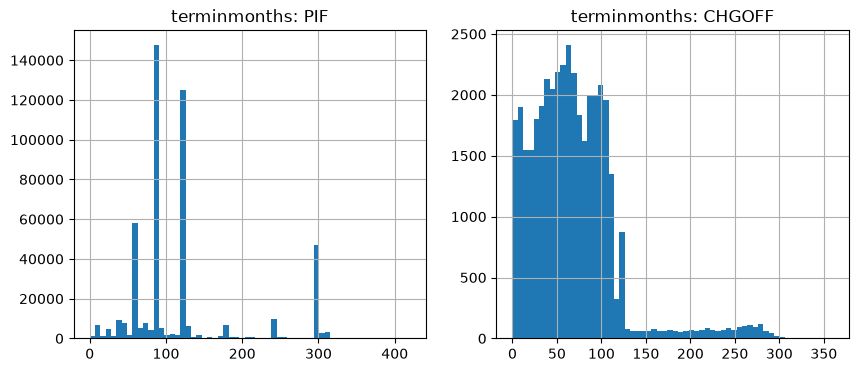

Non-rounded PIF:    13.29%
Non-rounded CHGOFF: 88.50%
         terminmonths
default              
0          118.833392
1           66.913329


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[df["default"] == 0]["terminmonths"].hist(bins=60, ax=axes[0])
axes[0].set_title("terminmonths: PIF")
df[df["default"] == 1]["terminmonths"].hist(bins=60, ax=axes[1])
axes[1].set_title("terminmonths: CHGOFF")
plt.show()

non_round_pif    = (df[df["default"] == 0]["terminmonths"] % 12 != 0).mean()
non_round_chgoff = (df[df["default"] == 1]["terminmonths"] % 12 != 0).mean()
print(f"Non-rounded PIF:    {non_round_pif:.2%}")
print(f"Non-rounded CHGOFF: {non_round_chgoff:.2%}")

print(df.groupby("default")[["terminmonths"]].mean())

In [16]:
# df.drop(columns=["terminmonths"], inplace=True)

## Business Age Inconsistency
There was a clear shift in recording methodology in 2018. It changed from many specific brackets: <1, 2-3, 3-4, 4-5, 5+, to a more general system of <2 or >2. Remapping was attempted. New businesses have a slightly higher default rate which is expected. There is some overlap between the categories. A feature that means different things every year is worse than no feature at all. Startups are the only consistent category which will be kept as a binary flag.

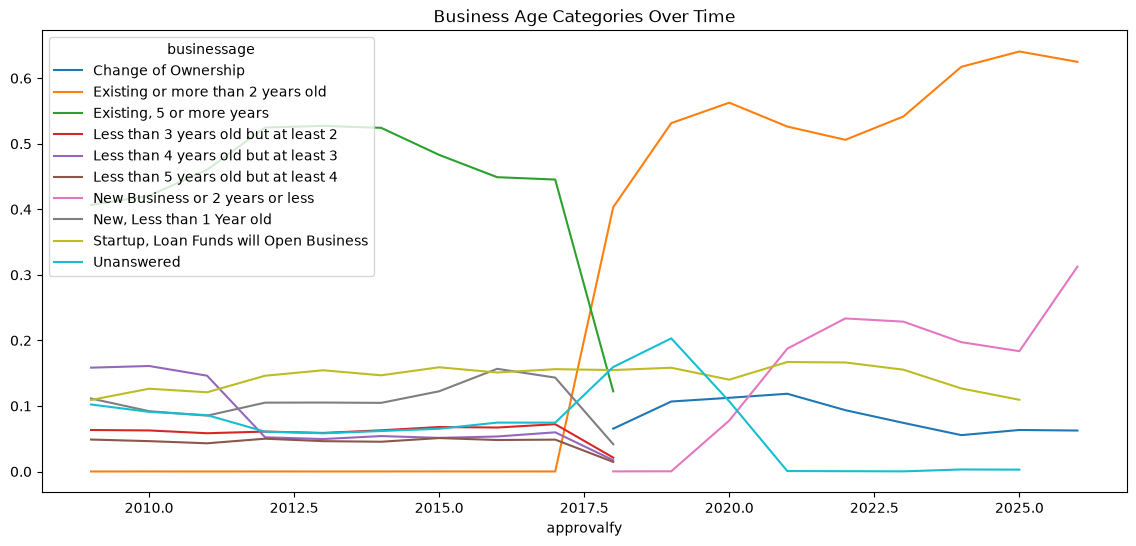

In [17]:
age_by_year = (df.groupby(["approvalfy", "businessage"]).size().unstack())
age_by_year_pct = age_by_year.div(age_by_year.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
age_by_year_pct.plot(ax=ax)
ax.set_title("Business Age Categories Over Time")
plt.show()

businessage
Change of Ownership                       0.053399
Existing or more than 2 years old         0.086885
Existing, 5 or more years                 0.060453
Less than 3 years old but at least 2      0.091573
Less than 4 years old but at least 3      0.074809
Less than 5 years old but at least 4      0.084940
New Business or 2 years or less           0.126587
New, Less than 1 Year old                 0.084565
Startup, Loan Funds will Open Business    0.089744
Unanswered                                0.079018
Name: default, dtype: float64


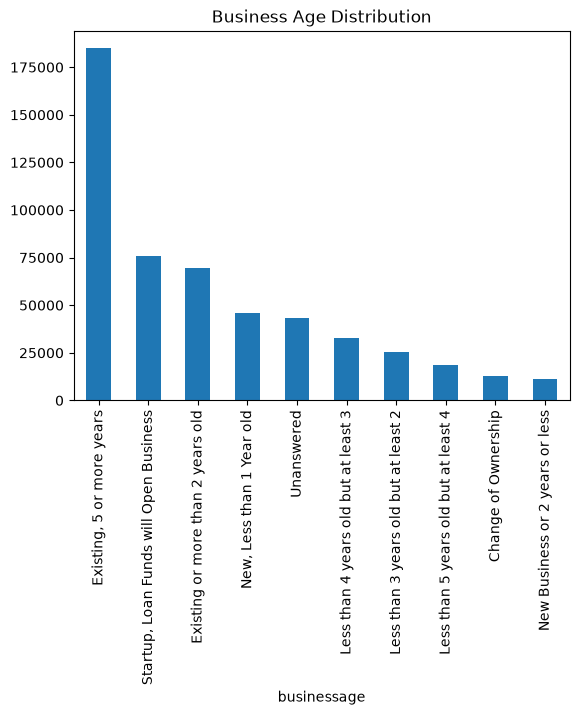

In [18]:
print(df.groupby("businessage")["default"].mean())
df["businessage"].value_counts().plot(kind="bar", title="Business Age Distribution")
plt.show()

age
established    0.071185
new            0.091060
other          0.073196
Name: default, dtype: float64


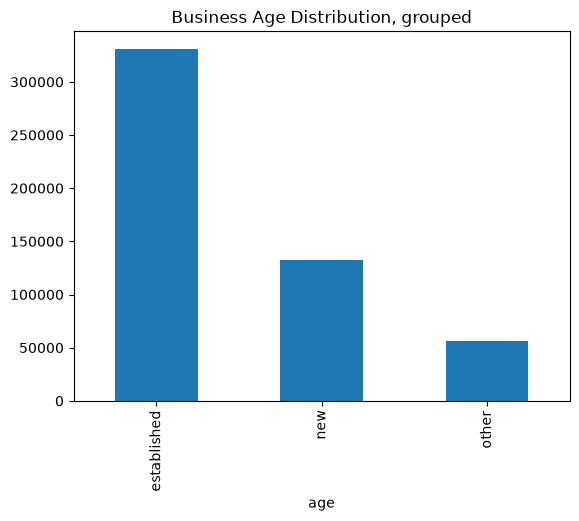

In [19]:
age_dict = {
    "Change of Ownership": "other",
    "Existing or more than 2 years old": "established",
    "Existing, 5 or more years": "established",
    "Less than 3 years old but at least 2": "established",
    "Less than 4 years old but at least 3": "established",
    "Less than 5 years old but at least 4": "established",
    "New Business or 2 years or less": "new",
    "New, Less than 1 Year old": "new",
    "Startup, Loan Funds will Open Business": "new",
    "Unanswered": "other"}

df["age"] = df["businessage"].map(age_dict)

print(df.groupby("age")["default"].mean())
df["age"].value_counts().plot(kind="bar", title="Business Age Distribution, grouped")
plt.show()

In [20]:
df["is_startup"] = (df["businessage"] == "Startup, Loan Funds will Open Business").astype(int)
print(f"Startup rate: {df['is_startup'].mean():.2%}")
print(f"Startup default: {df[df['is_startup']==1]['default'].mean():.2%}")
print(f"Non-startup default: {df[df['is_startup']==0]['default'].mean():.2%}")

Startup rate: 14.59%
Startup default: 8.97%
Non-startup default: 7.42%


### Loan Size

Smaller loans have higher default rates.

In [21]:
loan_bins   = [0, 50_000, 150_000, 250_000, 350_000, 500_000, 2_000_000, float("inf")]
loan_labels = ["<50k", "50k-150k", "150k-250k", "250k-350k", "350k-500k", "500k-2M", "2M+"]

df["loan_size_bucket"] = pd.cut(df["grossapproval"], bins=loan_bins, labels=loan_labels, right=True)

print(
    df.groupby("loan_size_bucket", observed=True)["default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate"})
    .round(3)
)

                  default_rate   count
loan_size_bucket                      
<50k                     0.091  187739
50k-150k                 0.088  122096
150k-250k                0.069   48287
250k-350k                0.072   40431
350k-500k                0.056   28623
500k-2M                  0.047   75315
2M+                      0.031   17528


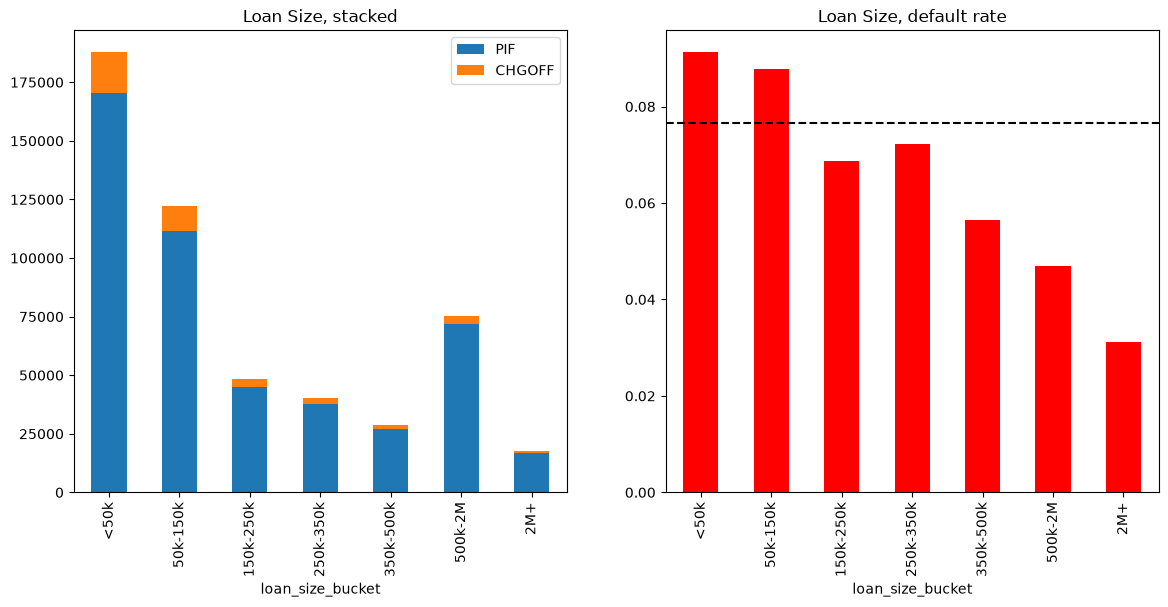

In [22]:
loan_counts = (
    df.groupby(["loan_size_bucket", "default"], observed=True)
    .size()
    .unstack()
    .rename(columns={0: "PIF", 1: "CHGOFF"})
)
loan_counts["total"]       = loan_counts["PIF"] + loan_counts["CHGOFF"]
loan_counts["default_rate"] = loan_counts["CHGOFF"] / loan_counts["total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

loan_counts[["PIF", "CHGOFF"]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Loan Size, stacked")
axes[0].legend(["PIF", "CHGOFF"])

loan_counts["default_rate"].plot(kind="bar", color="red", ax=axes[1])
axes[1].set_title("Loan Size, default rate")
axes[1].axhline(df["default"].mean(), color="black", linestyle="--")

plt.show()

### Job Supported

Using number of jobs supported as proxy for business size, smaller businesses have high default rates.

In [23]:
job_bins   = [0, 5, 10, 25, 50, 100, 200, float("inf")]
job_labels = ["1-5", "6-10", "11-25", "26-50", "51-100", "101-200", "201+"]

df["job_bucket"] = pd.cut(df["jobssupported"], bins=job_bins, labels=job_labels, right=True)

print(
    df.groupby("job_bucket", observed=True)["default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate"})
    .round(3)
)

            default_rate   count
job_bucket                      
1-5                0.084  212436
6-10               0.077   92908
11-25              0.072   85344
26-50              0.061   33483
51-100             0.052   12560
101-200            0.046    3770
201+               0.039     639


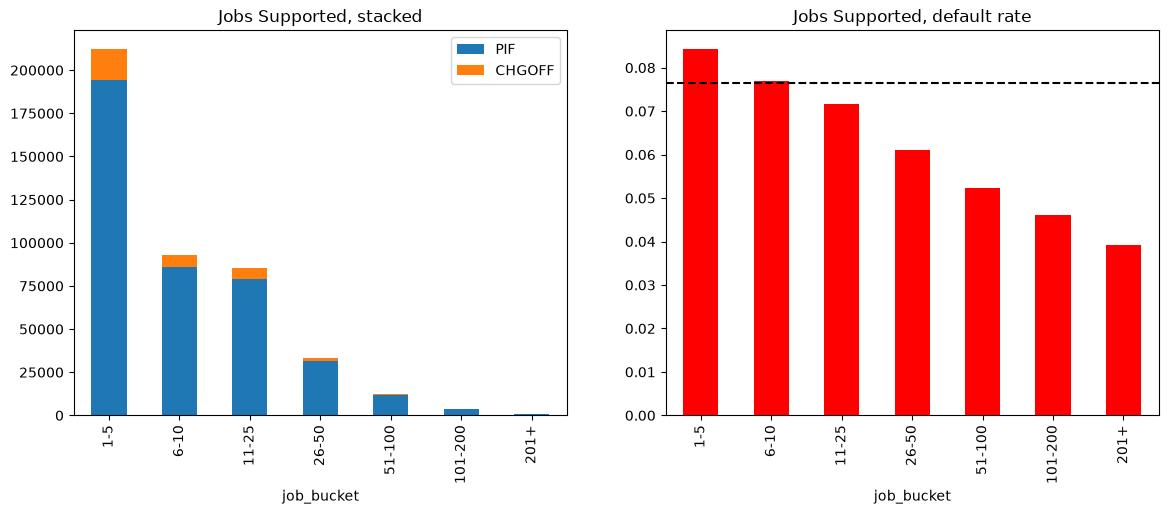

In [24]:
job_counts = (
    df.groupby(["job_bucket", "default"], observed=True)
    .size()
    .unstack()
    .rename(columns={0: "PIF", 1: "CHGOFF"})
)
job_counts["total"]       = job_counts["PIF"] + job_counts["CHGOFF"]
job_counts["default_rate"] = job_counts["CHGOFF"] / job_counts["total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_counts[["PIF", "CHGOFF"]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Jobs Supported, stacked")
axes[0].legend(["PIF", "CHGOFF"])

job_counts["default_rate"].plot(kind="bar", color="red", ax=axes[1])
axes[1].set_title("Jobs Supported, default rate")
axes[1].axhline(df["default"].mean(), color="black", linestyle="--")

plt.show()

In [25]:
df.columns

Index(['borrstate', 'grossapproval', 'approvalfy', 'initialinterestrate',
       'fixedorvariableinterestind', 'terminmonths', 'projectstate',
       'businesstype', 'businessage', 'loanstatus', 'revolverstatus',
       'jobssupported', 'collateralind', 'default', 'is_franchise', 'naics_2',
       'age', 'is_startup', 'loan_size_bucket', 'job_bucket'],
      dtype='str')

### Year Periods

Default rates appear to increase over time, however there hasn't been a large enough sample size in recent years to say anything significant. Most loans have not had enough time to complete yet.

In [26]:
year_bins   = [2009, 2013, 2017, 2021, 2025]
year_labels = ["2009-13", "2013-17", "2017-21", "2021-25"]

df["period"] = pd.cut(df["approvalfy"], bins=year_bins, labels=year_labels, right=True)

year_summary = (
    df.groupby("period", observed=True)["default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "Loans"})
)
print(year_summary.round(4))

         default_rate   Loans
period                       
2009-13        0.0606  158023
2013-17        0.0738  191832
2017-21        0.0797  112633
2021-25        0.1231   26384


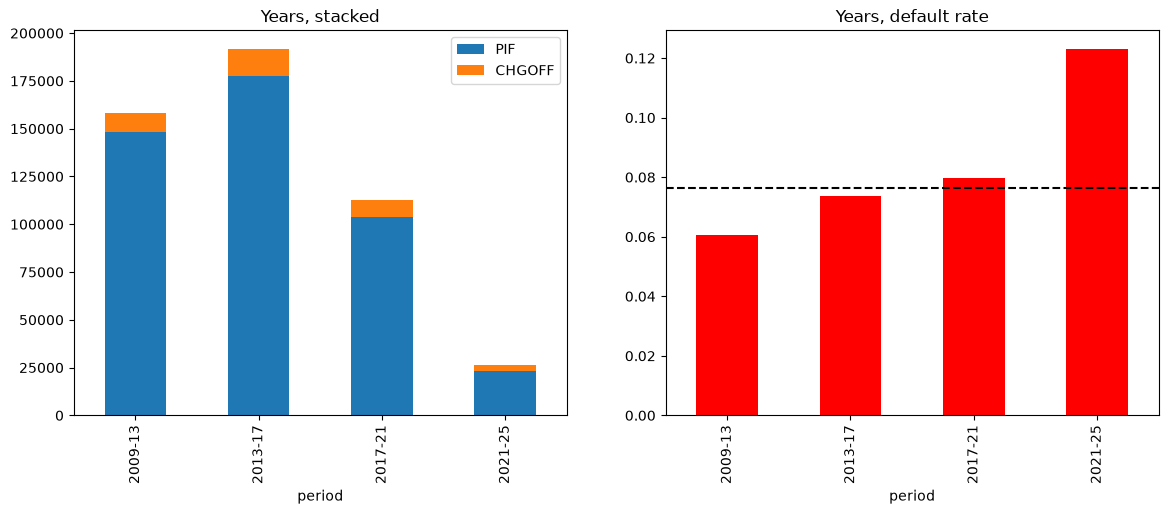

In [27]:
year_counts = (
    df.groupby(["period", "default"], observed=True)
    .size()
    .unstack()
    .rename(columns={0: "PIF", 1: "CHGOFF"})
)
year_counts["total"]       = year_counts["PIF"] + year_counts["CHGOFF"]
year_counts["default_rate"] = year_counts["CHGOFF"] / year_counts["total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_counts[["PIF", "CHGOFF"]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Years, stacked")
axes[0].legend(["PIF", "CHGOFF"])

year_counts["default_rate"].plot(kind="bar", color="red", ax=axes[1])
axes[1].set_title("Years, default rate")
axes[1].axhline(df["default"].mean(), color="black", linestyle="--")

plt.show()

## State Info

When borrower state and project state are different, there is a siginifcant high default rate. This is strange. Operating businesses across states could be more challenging. This signial is worth flagging. We will take borrower states as it's the origination of operation for the business and frequency encode them with default rates by states since states are high cardinal. States with low instances will be inputed with the national default average.

In [28]:
df["state_mismatch"] = df["borrstate"] != df["projectstate"]
print(f"Mismatch rate: {df['state_mismatch'].mean():.2%}")
print(df.groupby("state_mismatch")["default"].mean())

Mismatch rate: 0.21%
state_mismatch
False    0.075402
True     0.599626
Name: default, dtype: float64


In [29]:
train_mask  = df["approvalfy"] <= 2018
global_mean = df.loc[train_mask, "default"].mean()

state_rates = (
    df.loc[train_mask]
    .groupby("borrstate")["default"]
    .agg(["mean", "count"])
)

state_rates["encoded"] = state_rates.apply(lambda r: r["mean"] if r["count"] >= 30 else global_mean, axis=1)
df["borrstate_freq"] = df["borrstate"].map(state_rates["encoded"]).fillna(global_mean)
print(state_rates[["mean", "count", "encoded"]].sort_values("mean", ascending=False).head(10).round(4))

             mean  count  encoded
borrstate                        
MP         0.2000      5   0.0746
VI         0.1176     85   0.1176
FL         0.1111  18935   0.1111
SC         0.1030   3077   0.1030
NJ         0.1019  10601   0.1019
TX         0.0969  32131   0.0969
AL         0.0959   3087   0.0959
LA         0.0934   3384   0.0934
IL         0.0928  13495   0.0928
NV         0.0914   3129   0.0914


In [30]:
# columns for eda purposes only
df.drop(columns=["age", "loan_size_bucket", "job_bucket", "period"], inplace=True)

In [31]:
df.to_csv("sba_data.csv", index=False)